### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2

In [61]:
import albumentations as A

In [150]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics

In [113]:
import tensorflow as tf
from tensorflow import io, image, data
from tensorflow.keras import layers, Model, optimizers, callbacks, utils

### Step 2: Constant

In [70]:
AUTO = data.experimental.AUTOTUNE
IMAGE_FOLD = './data/flowers/'
BATCH_SIZE = 64
IMG_HEIGH = 224
IMG_WIDTH = 224
IMG_CHANNEL = 3

### Step 3: Load Data

In [96]:
labels = os.listdir(IMAGE_FOLD)

In [97]:
df = pd.DataFrame()

In [98]:
for label in labels:
    df_label = pd.DataFrame(
        {
        'id': os.listdir(os.path.join(IMAGE_FOLD, label)),
        'label': label
        }
    )
    df = pd.concat([df, df_label], ignore_index=True)

In [99]:
df

,id,label
0,100080576_f52e8ee070_n.jpg,daisy
1,10140303196_b88d3d6cec.jpg,daisy
2,10172379554_b296050f82_n.jpg,daisy
3,10172567486_2748826a8b.jpg,daisy
4,10172636503_21bededa75_n.jpg,daisy
...,...,...
4929,9831362123_5aac525a99_n.jpg,tulip
4930,9870557734_88eb3b9e3b_n.jpg,tulip
4931,9947374414_fdf1d0861c_n.jpg,tulip
4932,9947385346_3a8cacea02_n.jpg,tulip


### Step 4: Exploaring Data

#### Target Distribution

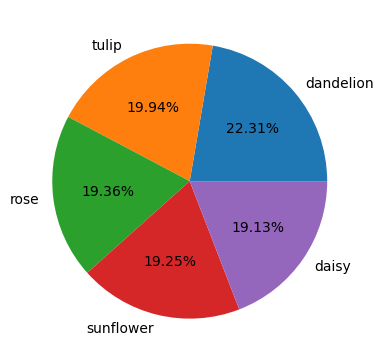

In [100]:
temp = df['label'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(
    temp,
    autopct='%.2f%%',
    labels=temp.index
)
plt.tight_layout()

#### Show Image

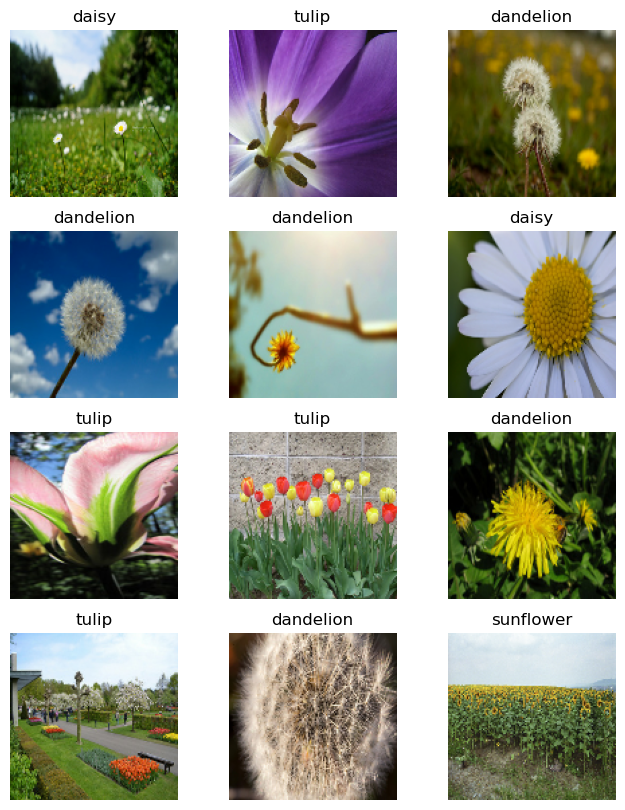

In [101]:
plt.figure(figsize=(8, 10))
for i in range(12):
    plt.subplot(4, 3, i+1)
    k = np.random.randint(0, len(df))
    img_id = df.loc[k, 'id']
    target = df.loc[k, 'label']
    img = io.read_file(f'{IMAGE_FOLD}{target}/{img_id}')
    img = image.decode_jpeg(img)
    img = image.resize(img, (125, 125))
    plt.imshow(img/255.0)
    plt.title(target)
    plt.axis('off')

### Step 5: Feature Engineering

In [102]:
le = LabelEncoder()

In [103]:
df['label_id'] = le.fit_transform(df['label'])

### Step 6: Preparing Data

#### Split Data

In [104]:
train, test = train_test_split(
    df,
    test_size=0.4,
    random_state=42
)

In [105]:
value, test = train_test_split(
    test,
    test_size=0.5,
    random_state=42
)

#### Albumentation

In [106]:
transform_train = A.Compose(
    [
        A.Resize(IMG_HEIGH, IMG_WIDTH),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomGamma(p=0.5),
        A.CoarseDropout(p=0.2),
        A.RandomBrightnessContrast(p=0.2)
    ]
)

In [107]:
trainsform_value = A.Compose(
    [
        A.Resize(IMG_HEIGH, IMG_WIDTH)
    ]
)

#### Build Generator

In [108]:
def generator(df, img_shape, is_train):
    def gen():
        for _, row in df.iterrows():
            img_id = row['id']
            label = row['label']
            try:
                img = cv2.imread(f'{IMAGE_FOLD}{label}/{img_id}')
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            except:
                print(label)
                print(img_id)
            if is_train:
                img = transform_train(image=img)['image']
            else:
                img = trainsform_value(image=img)['image']
            img = img.astype('float32') / 255.0
            yield img, row['label_id']

    return data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec(shape=img_shape, dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.uint8)
        )
    )

In [109]:
def get_generator(df, img_shape, batch_size, is_train=True):
    gen = generator(df, img_shape, is_train)
    gen = gen.map(
        lambda x, y: (x, tf.one_hot(y, len(le.classes_)))
    )
    if is_train:
        gen = gen.shuffle(len(df))
    gen = gen.batch(batch_size)
    gen = gen.prefetch(AUTO)
    return gen

In [110]:
train_generator = get_generator(train, (IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL), BATCH_SIZE)
value_generator = get_generator(value, (IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL), BATCH_SIZE, is_train=False)
test_generator = get_generator(test, (IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL), BATCH_SIZE, is_train=False)

In [112]:
for img, label in train_generator.take(1):
    print(img.shape, label.shape)

(64, 224, 224, 3) (64, 5)


### Step 7: Model Development

#### Build Model

In [116]:
inputs = layers.Input(shape=(IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL))
x = layers.Conv2D(64, kernel_size=5, padding='same', activation='relu')(inputs)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(64, kernel_size=3, padding='same', activation='relu')(x)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(64, kernel_size=3, padding='same', activation='relu')(x)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(64, kernel_size=3, padding='same', activation='relu')(x)
x = layers.MaxPooling2D()(x)
x = layers.Flatten()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
outputs = layers.Dense(5, activation='softmax')(x)

In [117]:
model = Model(inputs, outputs)

In [118]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 224, 224, 64)        │           4,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 112, 112, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 56, 56, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 28, 28, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 28, 28, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │       6,423,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 5)                   │           2,565 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,543,301 (24.96 MB)

 Trainable params: 6,542,277 (24.96 MB)

 Non-trainable params: 1,024 (4.00 KB)

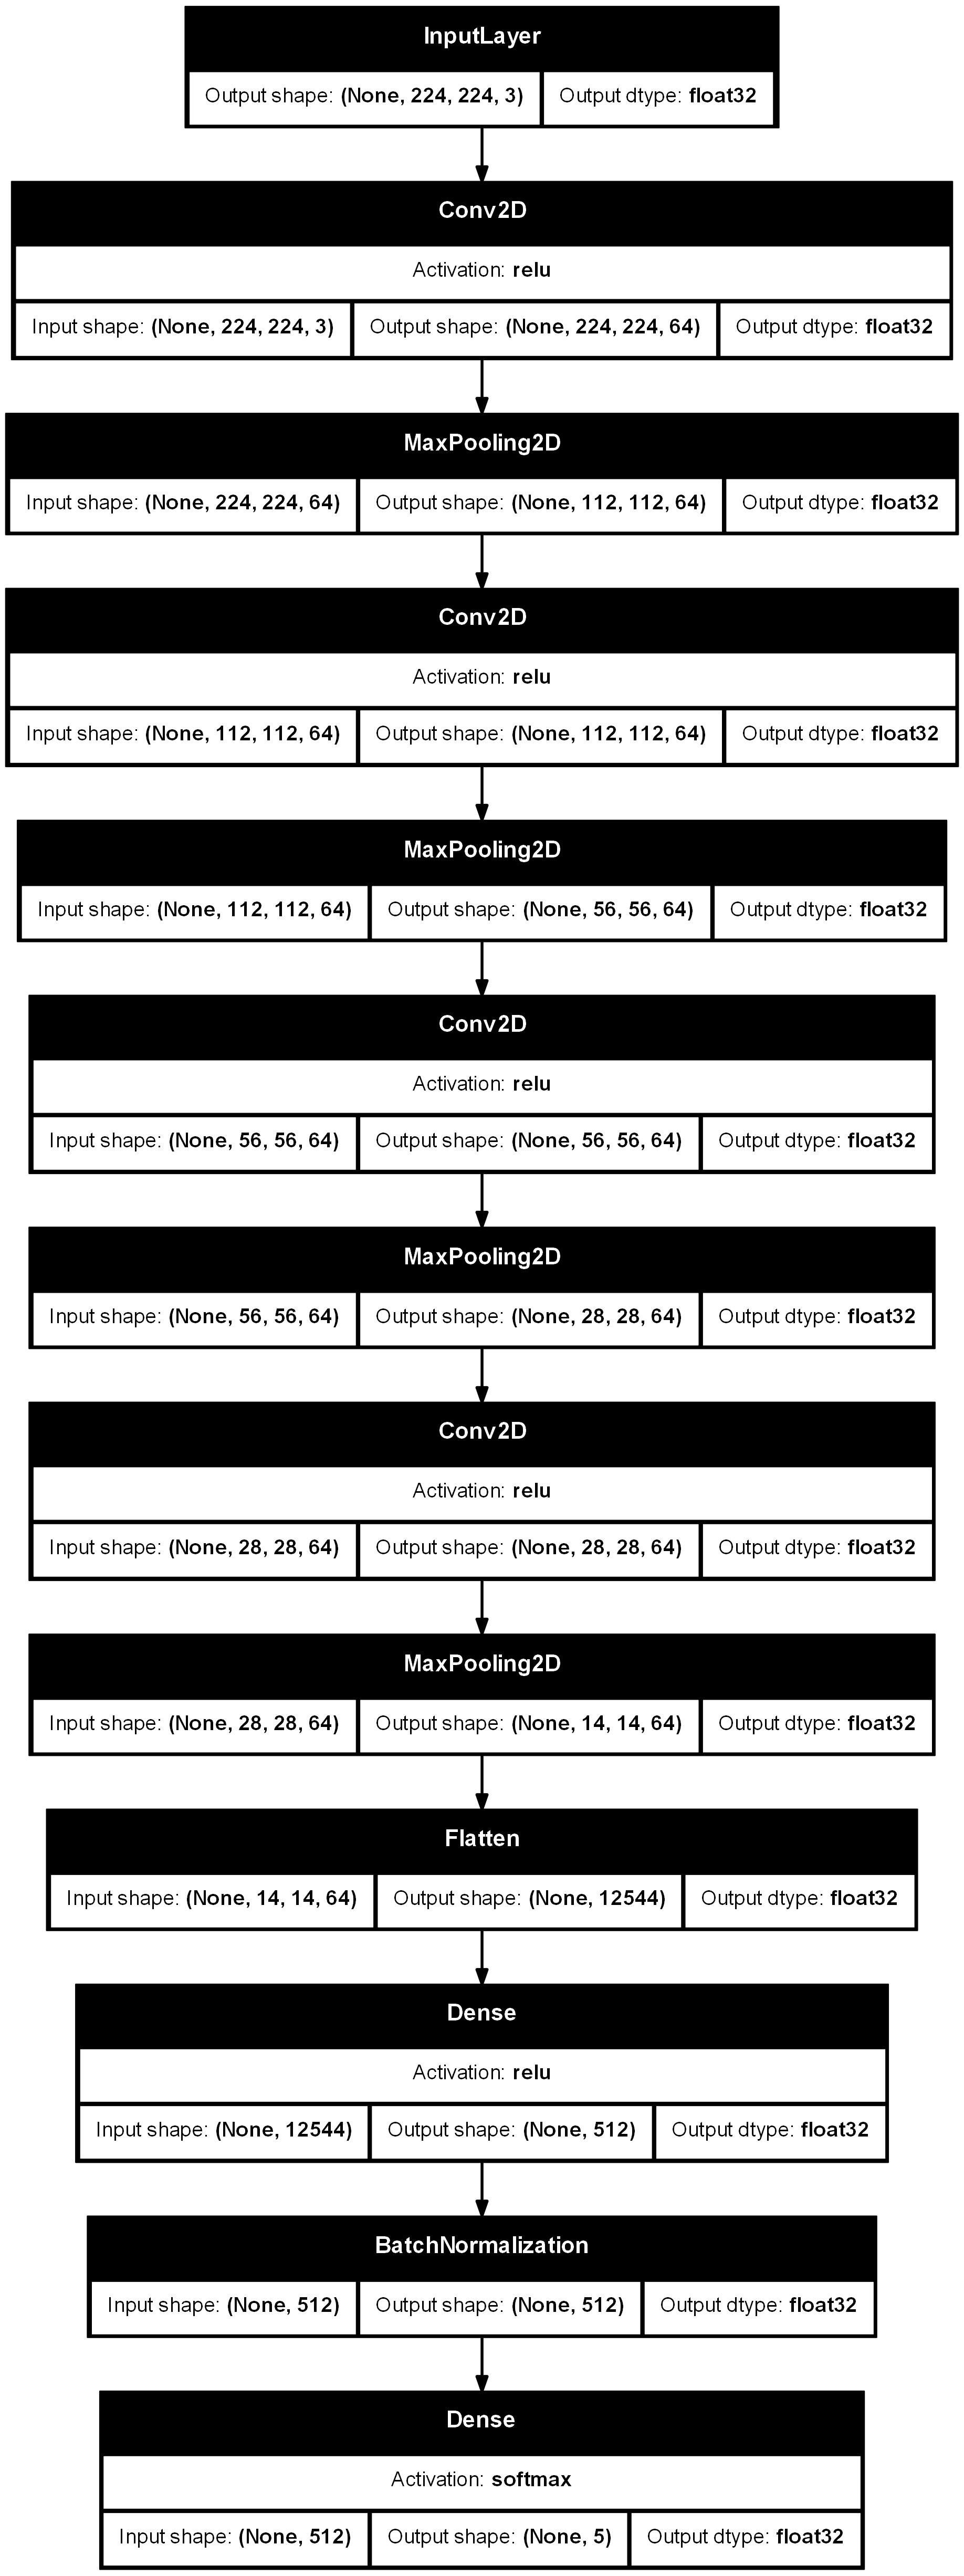

In [120]:
utils.plot_model(model, show_shapes=True, show_dtype=True, show_layer_activations=True)

### Model Compile

In [121]:
optimizer = optimizers.Adam(clipnorm=1.0)

In [122]:
model.compile(
    optimizer=optimizer,
    loss = 'categorical_crossentropy',
    metrics=['accuracy']
)

#### Training Model

In [123]:
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [125]:
lr_schedule = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2
)

In [126]:
history = model.fit(
    train_generator,
    validation_data=value_generator,
    epochs=30,
    callbacks=[early_stopping, lr_schedule]
)

Epoch 1/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 56s 990ms/step - accuracy: 0.4743 - loss: 1.3310 - val_accuracy: 0.3343 - val_loss: 1.6960 - learning_rate: 0.0010
Epoch 2/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.5514 - loss: 1.0985 - val_accuracy: 0.2827 - val_loss: 2.5971 - learning_rate: 0.0010
Epoch 3/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.5980 - loss: 1.0115 - val_accuracy: 0.5339 - val_loss: 1.1822 - learning_rate: 0.0010
Epoch 4/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.6368 - loss: 0.9361 - val_accuracy: 0.4944 - val_loss: 1.3220 - learning_rate: 0.0010
Epoch 5/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.6520 - loss: 0.8740 - val_accuracy: 0.5765 - val_loss: 1.1389 - learning_rate: 0.0010
Epoch 6/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.6801 - loss: 0.8078 - val_accuracy: 0.6707 - val_loss: 0.9295 - learning_rate: 0.0010
Epoch 7/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.6956 - loss: 0.7868 - val_accurac

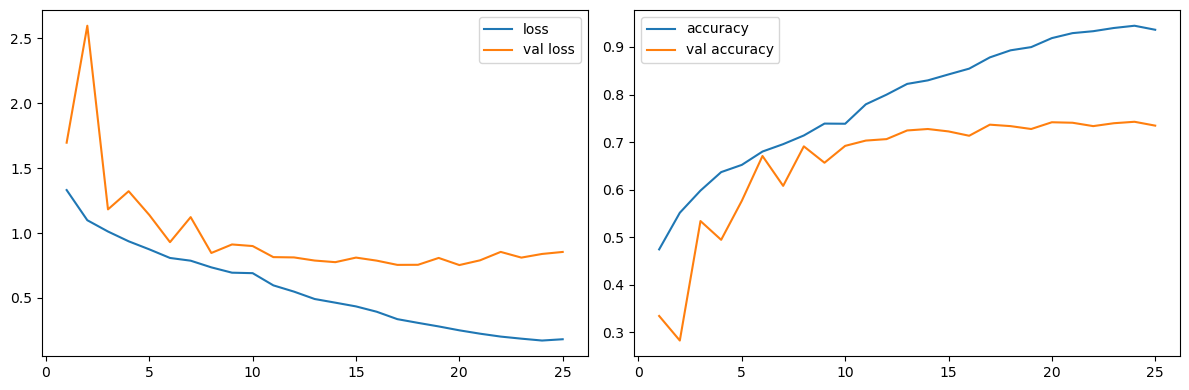

In [139]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, 26), history.history['loss'], label='loss')
plt.plot(range(1, 26), history.history['val_loss'], label='val loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(range(1, 26), history.history['accuracy'], label='accuracy')
plt.plot(range(1, 26), history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.tight_layout()

#### Evaluate Model

In [140]:
loss, acc = model.evaluate(test_generator)

16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 268ms/step - accuracy: 0.7173 - loss: 0.8566


In [142]:
print(f'test loss: {round(loss, 3)}, test accuracy: {round(acc, 3)}')

test loss: 0.857, test accuracy: 0.717


In [144]:
test_pred = model.predict(test_generator)

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 232ms/step


In [148]:
test['pred'] = le.inverse_transform(np.argmax(test_pred, axis=1))

In [152]:
confuse_matrix = metrics.confusion_matrix(test['label'], test['pred'])

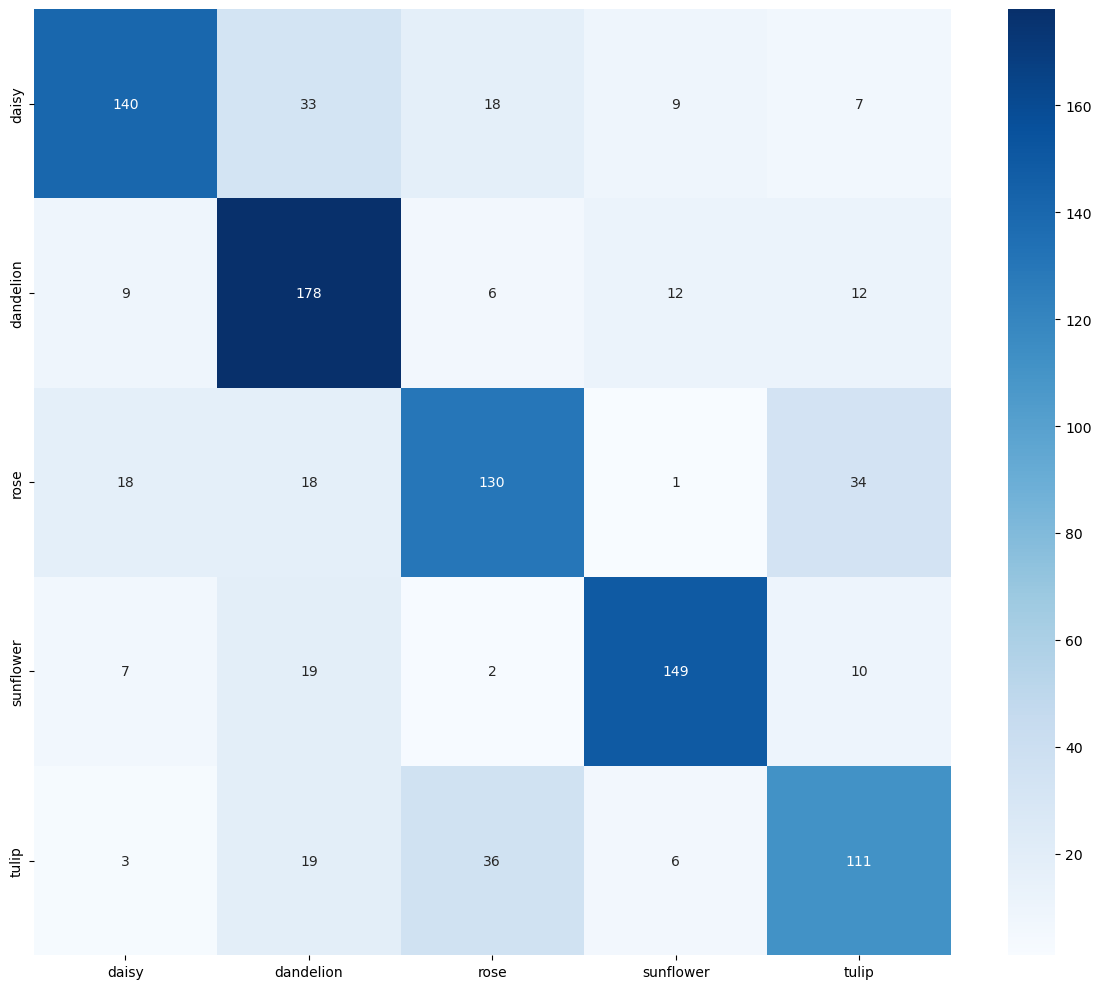

In [155]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    confuse_matrix,
    fmt='d',
    annot=True,
    cmap=plt.cm.Blues,
    xticklabels=le.classes_,
    yticklabels=le.classes_,
)
plt.tight_layout()

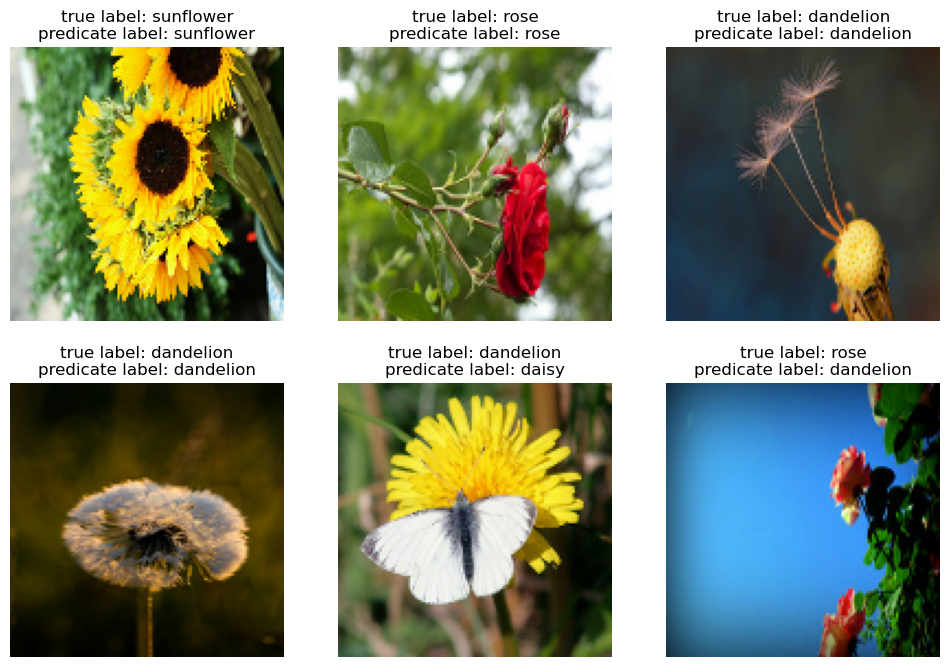

In [187]:
plt.figure(figsize=(12, 8))
for i in range(6):
    plt.subplot(2, 3, i+1)
    sample = test.sample(1)
    img_id = sample['id'].iloc[0]
    true_label = sample['label'].iloc[0]
    pred_label = sample['pred'].iloc[0]
    img = io.read_file(f'{IMAGE_FOLD}{true_label}/{img_id}')
    img = image.decode_jpeg(img)
    img = image.resize(img, (125, 125))
    plt.imshow(img/255.0)
    plt.title(f'true label: {true_label}\npredicate label: {pred_label}')
    plt.axis('off')